# 4 · The ranked ingredient **recipe** for the cardiac lineage

Combine intrinsic (TF) and extrinsic (L-R) evidence into a single ranked ingredient list with effect sizes and spatial-coincidence scores.

In [1]:
import sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")  # so `_pipeline` is importable when run from cookbook/
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import stereo_fate as sf
from _pipeline import build_result, TARGET_FATE, PROGENITOR
from pathlib import Path
FIG = Path("..") / "figures"; FIG.mkdir(exist_ok=True)
sns.set_context("talk")
# STANDING REQUIREMENT: resource guard first.
sf.check_resources(verbose=True)


stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    3.8 GB
  cpu_count      : 16
  n_jobs (capped): 15


ResourceReport(total_ram_gb=62.87113571166992, available_ram_gb=3.8326148986816406, cpu_count=16, n_jobs=15, est_dense_gb=None, fraction_of_available=None, safe=True, recommendation='ok')

In [2]:
adata = build_result()
recipe = adata.uns['stereo_fate']['recipe']
recipe.head(20)[['rank','ingredient','kind','role','effect_size','spatial_coincidence','ingredient_score']]

stereo-fate resource check
  total RAM      :   62.9 GB
  available RAM  :    3.8 GB
  cpu_count      : 16
  n_jobs (capped): 15


,rank,ingredient,kind,role,effect_size,spatial_coincidence,ingredient_score
0,1,Isl1,TF,intrinsic,2.007365,NaN,0.500000
1,2,Nppa,ligand,extrinsic,1.575763,0.423116,0.495007
2,3,Npr1,receptor,extrinsic,1.575763,0.423116,0.495007
3,4,Hand2,TF,intrinsic,1.952261,NaN,0.489839
4,5,Nkx2-5,TF,intrinsic,1.938423,NaN,0.487287
5,6,Fgfr2,receptor,extrinsic,1.449633,0.434472,0.484194
6,7,Fgf10,ligand,extrinsic,1.449633,0.434472,0.484194
7,8,Tbx20,TF,intrinsic,1.893563,NaN,0.479014
8,9,Tbx5,TF,intrinsic,1.879857,NaN,0.476487
9,10,Mef2c,TF,intrinsic,1.800356,NaN,0.461827


### Top ingredients, colored by kind

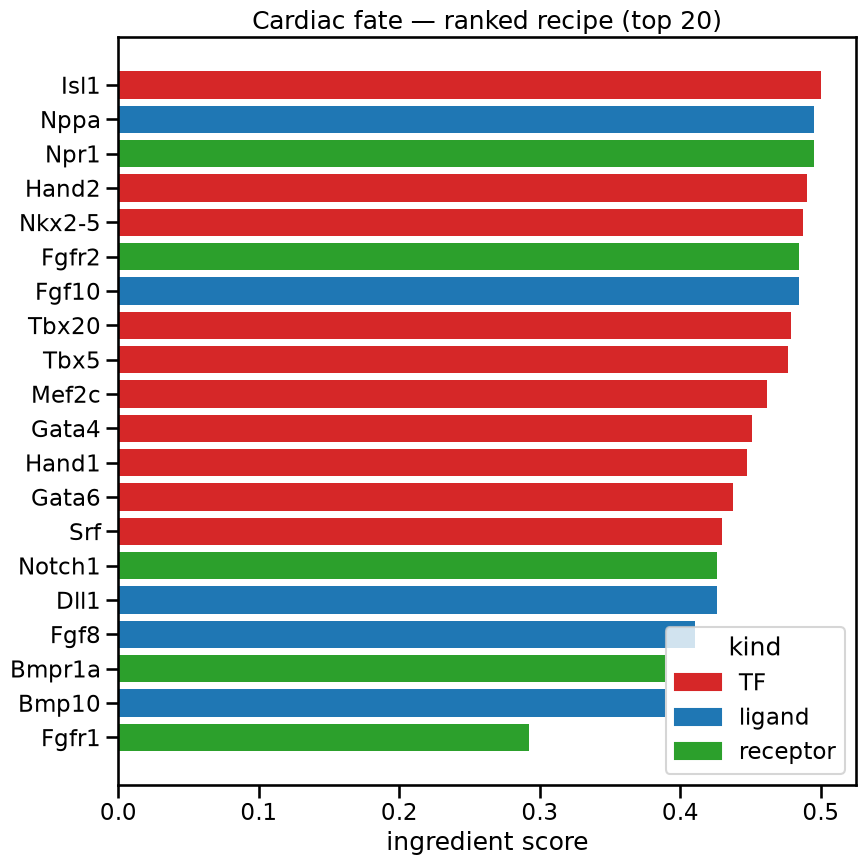

In [3]:
top=recipe.head(20).iloc[::-1]
palette={'TF':'#d62728','ligand':'#1f77b4','receptor':'#2ca02c'}
colors=[palette.get(k.split('+')[0],'#7f7f7f') for k in top['kind']]
fig,ax=plt.subplots(figsize=(9,9))
ax.barh(top['ingredient'], top['ingredient_score'], color=colors)
ax.set_xlabel('ingredient score'); ax.set_title(f'{TARGET_FATE} fate — ranked recipe (top 20)')
handles=[plt.Rectangle((0,0),1,1,color=c) for c in palette.values()]
ax.legend(handles,palette.keys(),title='kind')
fig.tight_layout(); fig.savefig(FIG/'04_recipe.png', dpi=150, bbox_inches='tight'); plt.show()